1. Імпорти

In [3]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 500)

2. Завантаження JSONL

In [4]:
FILE_PATH = "../data/raw/CEJavaRaw.jsonl"

data = []

with open(FILE_PATH, "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

df = pd.DataFrame(data)

print("Shape:", df.shape)

Shape: (239, 4)


3. Перший огляд

In [5]:
df.head()


,question_id,input,signature,docstring
0,6367676d1a6d9265ec018229,"/** \n * Trim the elements of the given String array, calling <code>String.trim()</code> on each of them.\n * @param array the original String array\n * @return the resulting array (of the same size) with trimmed elements\n */\n\npublic static String[] trimArrayElements(String[] array){",public static String[] trimArrayElements(String[] array){,"/** \n * Trim the elements of the given String array, calling <code>String.trim()</code> on each of them.\n * @param array the original String array\n * @return the resulting array (of the same size) with trimmed elements\n */\n"
1,6367670b1a6d9265ec017a00,"/** \n * <p>Checks whether two arrays are the same length, treating <code>null</code> arrays as length <code>0</code>.</p>\n * @param array1 the first array, may be <code>null</code>\n * @param array2 the second array, may be <code>null</code>\n * @return <code>true</code> if length of arrays matches, treating<code>null</code> as an empty array\n */\n\npublic static boolean isSameLength(final byte[] array1,final byte[] array2){","public static boolean isSameLength(final byte[] array1,final byte[] array2){","/** \n * <p>Checks whether two arrays are the same length, treating <code>null</code> arrays as length <code>0</code>.</p>\n * @param array1 the first array, may be <code>null</code>\n * @param array2 the second array, may be <code>null</code>\n * @return <code>true</code> if length of arrays matches, treating<code>null</code> as an empty array\n */\n"
2,636766a91a6d9265ec0175c2,/** \n * Pops an abstract type from the output frame stack and returns its value.\n * @return the abstract type that has been popped from the output frame stack.\n */\n\nprivate int pop(){,private int pop(){,/** \n * Pops an abstract type from the output frame stack and returns its value.\n * @return the abstract type that has been popped from the output frame stack.\n */\n
3,636767081a6d9265ec017989,"/** \n * <p>Converts an array of object Booleans to primitives.</p> <p>This method returns <code>null</code> for a <code>null</code> input array.</p>\n * @param array a <code>Boolean</code> array, may be <code>null</code>\n * @return a <code>boolean</code> array, <code>null</code> if null array input\n * @throws NullPointerException if array content is <code>null</code>\n */\n\npublic static boolean[] toPrimitive(final Boolean[] array){",public static boolean[] toPrimitive(final Boolean[] array){,"/** \n * <p>Converts an array of object Booleans to primitives.</p> <p>This method returns <code>null</code> for a <code>null</code> input array.</p>\n * @param array a <code>Boolean</code> array, may be <code>null</code>\n * @return a <code>boolean</code> array, <code>null</code> if null array input\n * @throws NullPointerException if array content is <code>null</code>\n */\n"
4,6367672d1a6d9265ec017c73,"/** \n * Returns true if the message should be printed in the given timestamp, otherwise returns false. If this method returns false, the message will not be printed. The timestamp is in seconds granularity. \n */\n\npublic boolean shouldPrintMessage(int timestamp,String message){","public boolean shouldPrintMessage(int timestamp,String message){","/** \n * Returns true if the message should be printed in the given timestamp, otherwise returns false. If this method returns false, the message will not be printed. The timestamp is in seconds granularity. \n */\n"


4. Повний список колонок

In [6]:
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

1. question_id
2. input
3. signature
4. docstring


5. Типи даних

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   question_id  239 non-null    str  
 1   input        239 non-null    str  
 2   signature    239 non-null    str  
 3   docstring    239 non-null    str  
dtypes: str(4)
memory usage: 138.0 KB


6. Пропущені значення

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]

missing.sort_values(ascending=False)

Series([], dtype: int64)

7. Дублікати

In [9]:
print(
    "Duplicates:",
    df.duplicated().sum()
)


Duplicates: 0


8. Випадкові приклади

In [10]:
df.sample(5)

,question_id,input,signature,docstring
118,636766f21a6d9265ec017667,"/** \n * Reads a signed short value in this {@link ClassReader}. <i>This method is intended for {@link Attribute} sub classes, and is normally not needed by class generators or adapters.</i>\n * @param offset the start offset of the value to be read in this {@link ClassReader}.\n * @return the read value.\n */\n\npublic short readShort(final int offset){",public short readShort(final int offset){,"/** \n * Reads a signed short value in this {@link ClassReader}. <i>This method is intended for {@link Attribute} sub classes, and is normally not needed by class generators or adapters.</i>\n * @param offset the start offset of the value to be read in this {@link ClassReader}.\n * @return the read value.\n */\n"
174,636766a81a6d9265ec017586,/** \n * Pops the given number of abstract types from the output frame stack.\n * @param elements the number of abstract types that must be popped.\n */\n\nprivate void pop(final int elements){,private void pop(final int elements){,/** \n * Pops the given number of abstract types from the output frame stack.\n * @param elements the number of abstract types that must be popped.\n */\n
121,636767611a6d9265ec018116,"/** \n * Efficient way to compute the intersection between two sets\n * @param set1 set $1$\n * @param set2 set $2$\n * @return intersection of set $1$ and $2$\n */\n\nprivate Set<V> intersection(Set<V> set1,Set<V> set2){","private Set<V> intersection(Set<V> set1,Set<V> set2){",/** \n * Efficient way to compute the intersection between two sets\n * @param set1 set $1$\n * @param set2 set $2$\n * @return intersection of set $1$ and $2$\n */\n
115,636766f01a6d9265ec01763e,/** \n * Translate a MIME standard character set name into the Java equivalent.\n * @param charset The MIME standard name.\n * @return The Java equivalent for this name.\n */\n\nprivate static String javaCharset(String charset){,private static String javaCharset(String charset){,/** \n * Translate a MIME standard character set name into the Java equivalent.\n * @param charset The MIME standard name.\n * @return The Java equivalent for this name.\n */\n
73,636767021a6d9265ec0178bb,"/** \n * <p>Defensive programming technique to change a <code>null</code> reference to an empty one.</p> <p>This method returns an empty array for a <code>null</code> input array.</p> <p>As a memory optimizing technique an empty array passed in will be overridden with the empty <code>public static</code> references in this class.</p>\n * @param array the array to check for <code>null</code> or empty\n * @return the same array, <code>public static</code> empty array if <code>null</code> or e...",public static Double[] nullToEmpty(final Double[] array){,"/** \n * <p>Defensive programming technique to change a <code>null</code> reference to an empty one.</p> <p>This method returns an empty array for a <code>null</code> input array.</p> <p>As a memory optimizing technique an empty array passed in will be overridden with the empty <code>public static</code> references in this class.</p>\n * @param array the array to check for <code>null</code> or empty\n * @return the same array, <code>public static</code> empty array if <code>null</code> or e..."


9. Виділяємо текстові колонки

In [11]:
text_cols = df.select_dtypes(include=["object", "string"])

list(text_cols)


['question_id', 'input', 'signature', 'docstring']

10. Довжина текстових полів

In [12]:
for col in text_cols:

    df[f"{col}_len"] = (
        df[col]
        .fillna("")
        .astype(str)
        .str.len()
    )


11. Статистика довжин

In [13]:
length_cols = [
    c for c in df.columns
    if c.endswith("_len")
]

df[length_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
question_id_len,239.0,24.000000,0.000000,24.0,24.0,24.0,24.0,24.0
input_len,239.0,267.778243,136.096407,59.0,152.0,236.0,364.0,606.0
signature_len,239.0,55.435146,19.648673,18.0,43.0,53.0,64.5,134.0
docstring_len,239.0,211.343096,128.161103,25.0,109.0,183.0,309.5,553.0


12. Гістограми довжин

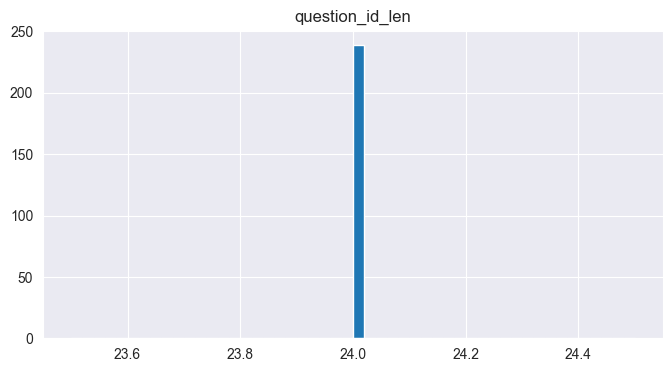

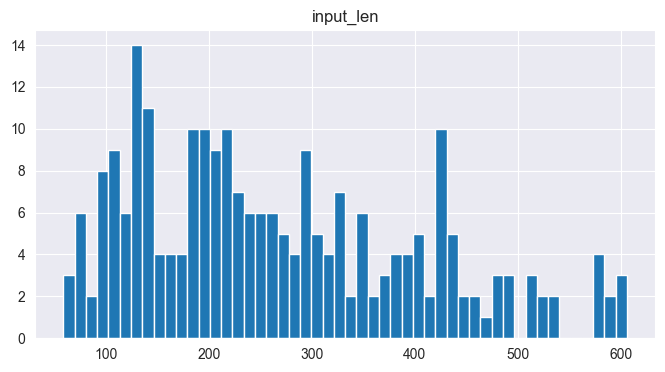

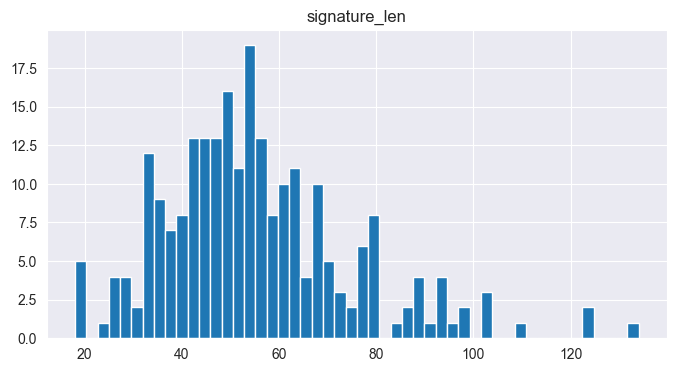

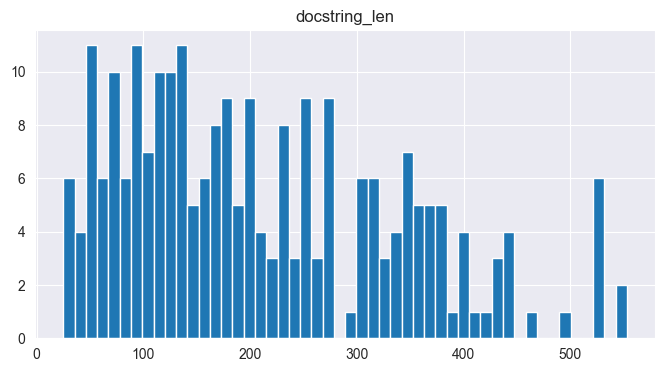

In [14]:
for col in length_cols:
    plt.figure(figsize=(8, 4))

    plt.hist(
        df[col],
        bins=50
    )

    plt.title(col)

    plt.show()

13. Аналіз ключових полів (якщо є)

In [15]:
important = ["prompt", "completion", "code"]

for col in important:
    if col in df.columns:
        print(f"{col}:")
        print(df[col].head(3))
        print("-" * 50)


14. Кореляційний аналіз

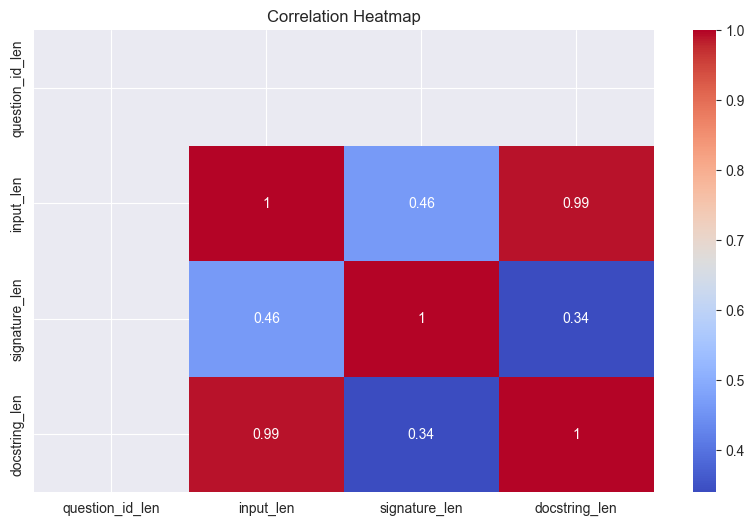

In [16]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

15. Outliers (аномалії)

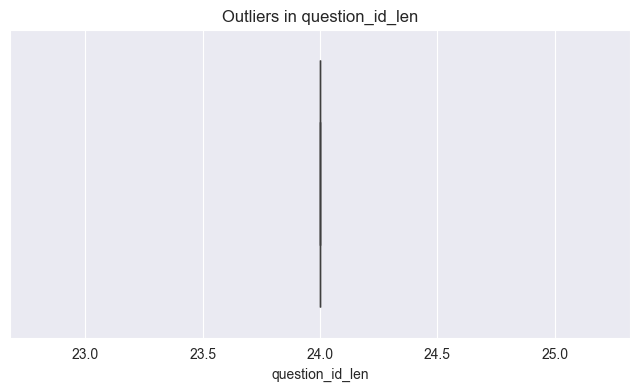

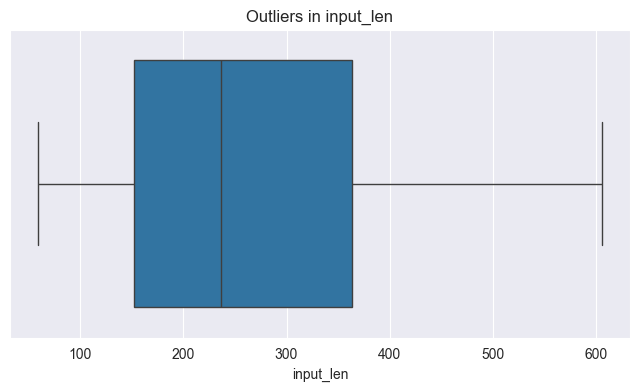

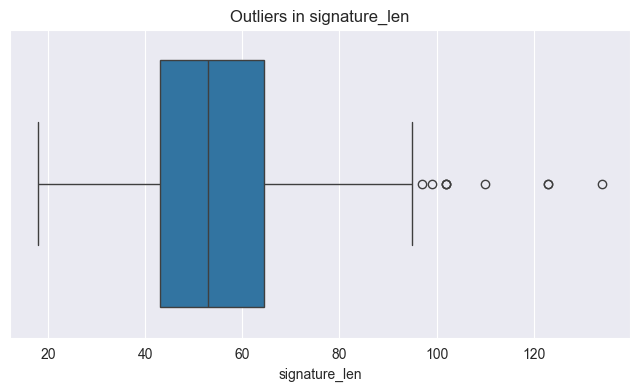

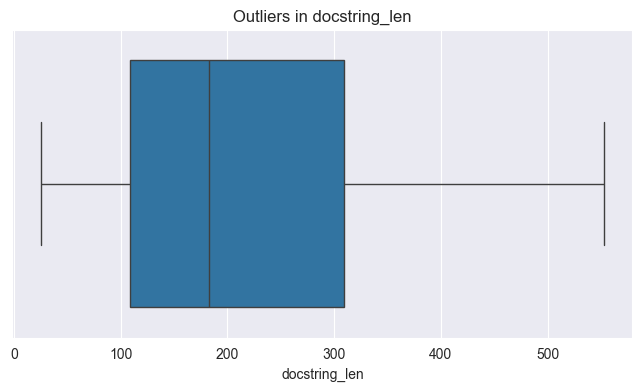

In [17]:
for col in length_cols:
    plt.figure(figsize=(8, 4))

    sns.boxplot(x=df[col])

    plt.title(f"Outliers in {col}")

    plt.show()

16. Аналіз кількості прикладів

In [18]:
if "language" in df.columns:
    print(df["language"].value_counts())

if "source" in df.columns:
    print(df["source"].value_counts())